# Analiza grešaka po tipovima mečeva

U ovoj svesci ćemo proveriti da li i gde šest sačuvanih modela (M0-M5) greše
više nego prosečno - na bliskim mečevima, kod tima na drugoj utakmici bez
odmora, na početku sezone i kod iznenađenja (favorit izgubio). Ovo je 05-03,
treći od tri dela sveske 05; ostala dva (zbirni grafici/kalibracija/kovid
sezone i ocena na test skupu) su odvojeni fajlovi da bi se moglo raditi
paralelno bez sudara u istom `.ipynb`.

Glavna analiza je na **validaciji**. Na kraju se isti obrazac ponavlja i na
testu, ali preko već sačuvanih predviđanja iz sveske 05-01 - test skup se u
celom projektu dodiruje tačno jednom, na kraju, i ova sveska to ne krši.

Skup podataka se može preuzeti sa [ove](https://www.kaggle.com/datasets/nathanlauga/nba-games) adrese.

## Priprema

In [1]:
import sys
sys.path.append("..")

import joblib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
from torch.utils.data import DataLoader

from src.config import BATCH_SIZE, ELO_HOME_BONUS, MODELS_PATH, PROCESSED_DATA_PATH, RANDOM_STATE, RESULTS_FILE
from src import data, evaluate, models, plotting, sequences, train

train.set_seed(RANDOM_STATE)

## Učitavanje pripremljenih podataka

Isti `atributi.csv` i `sekvence.npz` iz sveske 02, isti `validation` indeksi kao svuda u projektu - klasični modeli i mreže se poređuju nad identičnim mečevima.

In [2]:
X = pd.read_csv(PROCESSED_DATA_PATH / "atributi.csv")
splits = np.load(PROCESSED_DATA_PATH / "sekvence.npz")

train_idx, validation_idx = splits["train"], splits["validation"]
y_train, y_val = splits["labels"][train_idx], splits["labels"][validation_idx]
X_val = X.iloc[validation_idx].reset_index(drop=True)

home_val = splits["home_sequences"][validation_idx]
away_val = splits["away_sequences"][validation_idx]
context_val = splits["context"][validation_idx]

dataset_val = sequences.MatchSequenceDataset(home_val, away_val, context_val, y_val)
loader_val = DataLoader(dataset_val, batch_size=BATCH_SIZE, shuffle=False)

X_val.shape, len(dataset_val)

((2624, 52), 2624)

## Verovatnoće svih šest modela na validaciji

M0 nema sačuvan fajl - predviđa konstantnu osnovnu stopu, isto kao u svesci 03. M1 i M2 se učitavaju direktno. M3/M4/M5 dele istu `MatchPredictor` arhitekturu (sveska 04) i svaka ima pet sačuvanih modela, po jedan za svako seme; `hidden_size` se čita iz samih težina (`encoder.weight_hh_l0`), isti obrazac kao u svesci 05-01. Za analizu grešaka po meču dovoljan je jedan reprezentativni prolaz - seme `RANDOM_STATE`, isti izbor kao svuda u projektu - ne svih pet.

In [3]:
def ucitaj_mrezu(putanja, cell):
    """Rekonstruise mrezu iz tezina; hidden_size cita iz njih samih."""
    state = torch.load(putanja, weights_only=True)
    model = models.MatchPredictor(
        n_features=home_val.shape[-1],
        n_context=context_val.shape[-1],
        cell=cell,
        hidden_size=state["encoder.weight_hh_l0"].shape[1],
    )
    model.load_state_dict(state)
    model.eval()
    return model

model_m3 = ucitaj_mrezu(MODELS_PATH / f"rnn_seed{RANDOM_STATE}.pt", "rnn")
model_m4 = ucitaj_mrezu(MODELS_PATH / f"lstm_seed{RANDOM_STATE}.pt", "lstm")
model_m5 = ucitaj_mrezu(MODELS_PATH / f"gru_seed{RANDOM_STATE}.pt", "gru")

In [4]:
proba_m3, y_check = train.predict_proba(model_m3, loader_val)
proba_m4, _ = train.predict_proba(model_m4, loader_val)
proba_m5, _ = train.predict_proba(model_m5, loader_val)

# DataLoader bez mesanja (shuffle=False) cuva redosled dataset_val-a, koji je
# napravljen od istih validation_idx pozicija kao X_val - provera da poredjenje
# nize sme da spaja X_val i verovatnoce red-po-red
assert np.array_equal(y_check, y_val)

In [5]:
model_m1 = joblib.load(MODELS_PATH / "log_reg.joblib")
model_m2 = joblib.load(MODELS_PATH / "m2_xgboost.joblib")

base_rate = y_train.mean()

probabilities = {
    "M0 domacin": np.full(len(y_val), base_rate),
    "M1 log. reg.": model_m1.predict_proba(X_val)[:, 1],
    "M2 XGBoost": model_m2.predict_proba(X_val)[:, 1],
    "M3 RNN": proba_m3,
    "M4 LSTM": proba_m4,
    "M5 GRU": proba_m5,
}
predictions = {model: (proba >= 0.5).astype(int) for model, proba in probabilities.items()}

pd.Series({model: evaluate.compute_metrics(y_val, proba)["tacnost"] for model, proba in probabilities.items()})

M0 domacin      0.588796
M1 log. reg.    0.656250
M2 XGBoost      0.657012
M3 RNN          0.655107
M4 LSTM         0.657012
M5 GRU          0.660061
dtype: float64

Ove tačnosti se poklapaju (do sitnog numeričkog šuma) sa `reports/rezultati.csv` - očekivano, isti modeli, ista validacija, samo ponovo učitani radi ove analize.

## Definisanje tipova mečeva

Četiri kategorije, svaka kao podela validacije na dve grupe. `HOME_ELO`,
`HOME_REST_DAYS` i `HOME_IS_SEASON_START` u `atributi.csv` su skalirane
(`StandardScaler` iz sveske 02) - za čitljive pragove (razmak od 1 dana,
zastavica 0/1) moraju nazad u izvornu skalu. Skidanje skaliranja je linearno
(`x * scale_ + mean_`), pa ne treba ponovo graditi celu tabelu atributa da bi
se dobile sirove vrednosti - dovoljni su `scaler.joblib` i pozicija svake
kolone u `sequences.SCALED_COLUMNS`.

In [6]:
scaler = joblib.load(MODELS_PATH / "scaler.joblib")
column_position = {column: i for i, column in enumerate(sequences.SCALED_COLUMNS)}

def unscale(values, column):
    i = column_position[column]
    return values * scaler.scale_[i] + scaler.mean_[i]

**Blizina snaga (Elo razlika).** Manja razlika u Elo rejtingu znači neizvesniji meč - očekivano teže za model.

In [7]:
home_elo = unscale(X_val["HOME_ELO"], "ELO")
away_elo = unscale(X_val["AWAY_ELO"], "ELO")
elo_gap = (home_elo - away_elo).abs()

is_close_game = elo_gap <= elo_gap.median()
is_close_game.mean(), elo_gap.median()

(0.5, 93.6183721823403)

**Odmor / dve utakmice zaredom.** `REST_DAYS` je razmak od prethodnog meča tima - vrednost 1 znači da je tim igrao i dan pre ovog (poznat izvor umora u NBA).

In [8]:
home_rest = unscale(X_val["HOME_REST_DAYS"], "REST_DAYS")
away_rest = unscale(X_val["AWAY_REST_DAYS"], "REST_DAYS")
is_back_to_back = (home_rest.round() == 1) | (away_rest.round() == 1)

is_back_to_back.mean()

0.2778201219512195

**Početak sezone.** `IS_SEASON_START` obeležava prvi meč tima u sezoni - malo istorije za pokretne statistike, Elo tek posle regresije ka proseku.

In [9]:
home_start = unscale(X_val["HOME_IS_SEASON_START"], "IS_SEASON_START") > 0.5
away_start = unscale(X_val["AWAY_IS_SEASON_START"], "IS_SEASON_START") > 0.5
is_season_start = home_start | away_start

is_season_start.sum(), is_season_start.mean()

(32, 0.012195121951219513)

**Iznenađenje (favorit izgubio).** Favorit je tim sa većim Elo rejtingom, uz ELO_HOME_BONUS za domaćina - ista formula kao u compute_elo. Iznenađenje je meč gde je favorit izgubio.

In [10]:
home_favorite = (home_elo + ELO_HOME_BONUS) > away_elo
home_won = y_val.astype(bool)
is_upset = home_favorite != home_won

is_upset.mean()

0.34603658536585363

## Tačnost po tipu meča

Za svaku kategoriju - tačnost svakog modela na obe grupe. Isti obrazac crtanja kao "Tačnost osnovnih modela po skupu" u svesci 03: linija do vrednosti, tačka, boja po grupi (ne po modelu, jer se ovde svih šest modela već razlikuje po x-osi).

In [11]:
def accuracy_by_group(y_true, predictions_dict, is_group_a, label_a, label_b):
    rows = []
    for model, y_pred in predictions_dict.items():
        for is_a, label in [(is_group_a, label_a), (~is_group_a, label_b)]:
            rows.append({
                "model": model, "grupa": label,
                "tacnost": (y_pred[is_a] == y_true[is_a]).mean(), "n": int(is_a.sum()),
            })
    return pd.DataFrame(rows)

def plot_accuracy_by_group(df_group, title):
    modeli = [m for m in plotting.MODEL_ORDER if m in df_group["model"].unique()]
    grupe = df_group["grupa"].unique()
    x = np.arange(len(modeli))
    width = 0.35

    plotting.new_figure(title, "model", "tacnost")
    for i, grupa in enumerate(grupe):
        tacnosti = [
            df_group[(df_group["model"] == m) & (df_group["grupa"] == grupa)]["tacnost"].iloc[0]
            for m in modeli
        ]
        offset_x = x + (i - 0.5) * width
        for xi, val in zip(offset_x, tacnosti):
            plt.plot([xi, xi], [0, val], linewidth=2, color=f"C{i}")
        plt.scatter(offset_x, tacnosti, label=grupa, zorder=3, color=f"C{i}")
    plt.xticks(x, modeli)
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

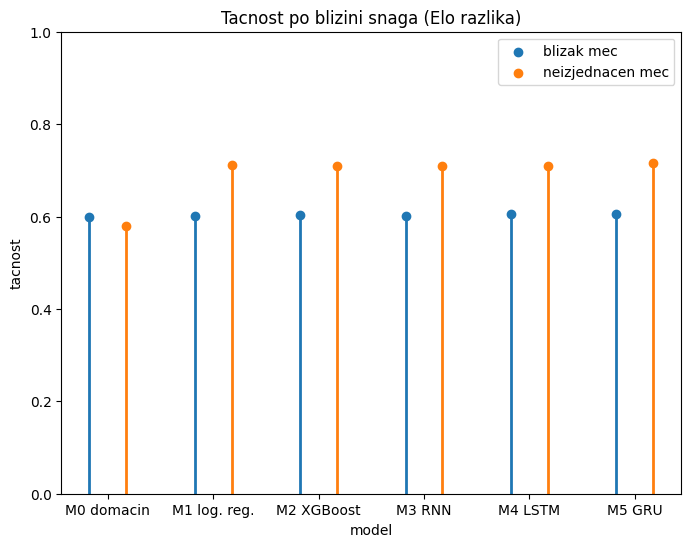

grupa,blizak mec,neizjednacen mec
model,,
M0 domacin,0.598323,0.579268
M1 log. reg.,0.601372,0.711128
M2 XGBoost,0.603659,0.710366
M3 RNN,0.600610,0.709604
M4 LSTM,0.605183,0.708841
M5 GRU,0.605183,0.714939


In [12]:
df_elo_gap = accuracy_by_group(y_val, predictions, is_close_game, "blizak mec", "neizjednacen mec")
plot_accuracy_by_group(df_elo_gap, "Tacnost po blizini snaga (Elo razlika)")
df_elo_gap.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

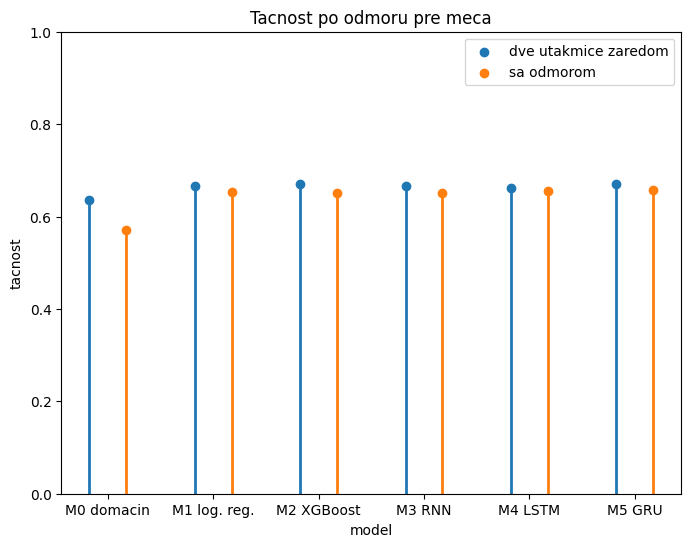

grupa,dve utakmice zaredom,sa odmorom
model,,
M0 domacin,0.635117,0.570976
M1 log. reg.,0.666667,0.652243
M2 XGBoost,0.670782,0.651715
M3 RNN,0.666667,0.650660
M4 LSTM,0.662551,0.654881
M5 GRU,0.669410,0.656464


In [13]:
df_rest = accuracy_by_group(y_val, predictions, is_back_to_back, "dve utakmice zaredom", "sa odmorom")
plot_accuracy_by_group(df_rest, "Tacnost po odmoru pre meca")
df_rest.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

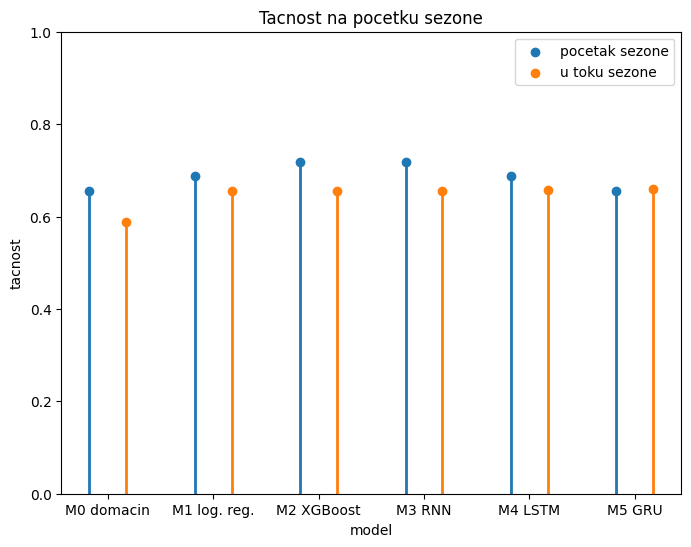

grupa,pocetak sezone,u toku sezone
model,,
M0 domacin,0.65625,0.587963
M1 log. reg.,0.68750,0.655864
M2 XGBoost,0.71875,0.656250
M3 RNN,0.71875,0.654321
M4 LSTM,0.68750,0.656636
M5 GRU,0.65625,0.660108


In [14]:
df_season = accuracy_by_group(y_val, predictions, is_season_start, "pocetak sezone", "u toku sezone")
plot_accuracy_by_group(df_season, "Tacnost na pocetku sezone")
df_season.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

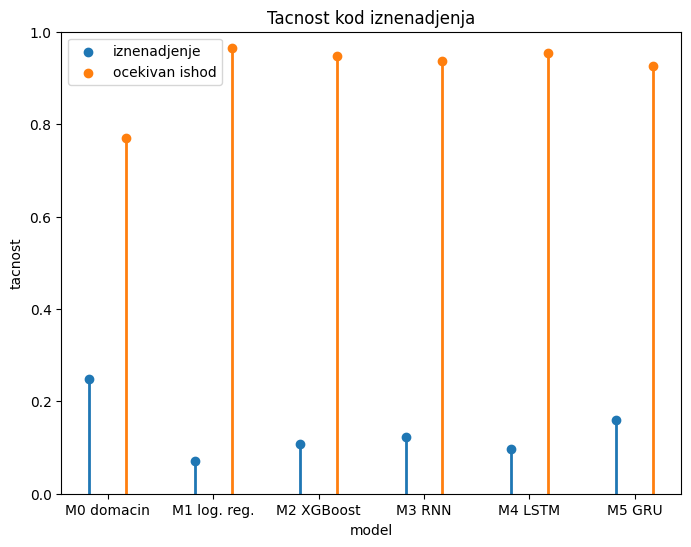

grupa,iznenadjenje,ocekivan ishod
model,,
M0 domacin,0.247797,0.769231
M1 log. reg.,0.071586,0.965618
M2 XGBoost,0.106828,0.948135
M3 RNN,0.122247,0.937063
M4 LSTM,0.096916,0.953380
M5 GRU,0.159692,0.924825


In [15]:
df_upset = accuracy_by_group(y_val, predictions, is_upset, "iznenadjenje", "ocekivan ishod")
plot_accuracy_by_group(df_upset, "Tacnost kod iznenadjenja")
df_upset.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

## Provera na test skupu

Sve gore je na validaciji. Test skup se u projektu dodiruje tačno jednom - to
je već urađeno u svesci 05-01, koja je sačuvala predviđanja svih šest modela
za test u `reports/predvidjanja-test.csv` (za mreže, prolaz sa semenom
`RANDOM_STATE`). Ovde se ta predviđanja samo učitavaju, ne računaju iznova -
test se time ne dodiruje po drugi put, samo se već izračunato ponovo koristi.

Iste četiri kategorije se ponavljaju nad testom, sa istim pragovima kao na
validaciji (npr. ista granica za "blizak meč"), da provera bude iskrena: ne
biramo novu granicu koja bi test skupu bolje odgovarala.

In [16]:
predvidjanja_test = pd.read_csv(RESULTS_FILE.parent / "predvidjanja-test.csv")

test_idx = splits["test"]
X_test = X.iloc[test_idx].reset_index(drop=True)

# GAME_ID ne stoji u atributi.csv, pa se sirovi skup ucitava samo zbog njega -
# isti obrazac kao u svesci 05-01, da bi spajanje bilo pouzdano umesto po
# pozicijskoj pretpostavci
df_games = data.clean_games(data.load_games())
X_test["GAME_ID"] = df_games.loc[splits["indices"][test_idx], "GAME_ID"].to_numpy()

test_merged = predvidjanja_test.merge(X_test, on="GAME_ID", how="left", validate="one_to_one")
assert len(test_merged) == len(predvidjanja_test), "spajanje je izgubilo ili udvostrucilo mecave"

test_merged.shape

(1323, 60)

In [17]:
home_elo_test = unscale(test_merged["HOME_ELO"], "ELO")
away_elo_test = unscale(test_merged["AWAY_ELO"], "ELO")
elo_gap_test = (home_elo_test - away_elo_test).abs()
is_close_game_test = elo_gap_test <= elo_gap.median()  # prag sa validacije, ne novi

home_rest_test = unscale(test_merged["HOME_REST_DAYS"], "REST_DAYS")
away_rest_test = unscale(test_merged["AWAY_REST_DAYS"], "REST_DAYS")
is_back_to_back_test = (home_rest_test.round() == 1) | (away_rest_test.round() == 1)

home_start_test = unscale(test_merged["HOME_IS_SEASON_START"], "IS_SEASON_START") > 0.5
away_start_test = unscale(test_merged["AWAY_IS_SEASON_START"], "IS_SEASON_START") > 0.5
is_season_start_test = home_start_test | away_start_test

home_favorite_test = (home_elo_test + ELO_HOME_BONUS) > away_elo_test
home_won_test = test_merged["y_true"].astype(bool)
is_upset_test = home_favorite_test != home_won_test

y_test_true = test_merged["y_true"].to_numpy()
predictions_test = {model: (test_merged[model] >= 0.5).astype(int).to_numpy() for model in probabilities}

pd.Series({
    "blizak mec": is_close_game_test.mean(),
    "dve utakmice zaredom": is_back_to_back_test.mean(),
    "pocetak sezone": is_season_start_test.sum(),
    "iznenadjenje": is_upset_test.mean(),
})

blizak mec               0.528345
dve utakmice zaredom     0.284958
pocetak sezone          16.000000
iznenadjenje             0.364324
dtype: float64

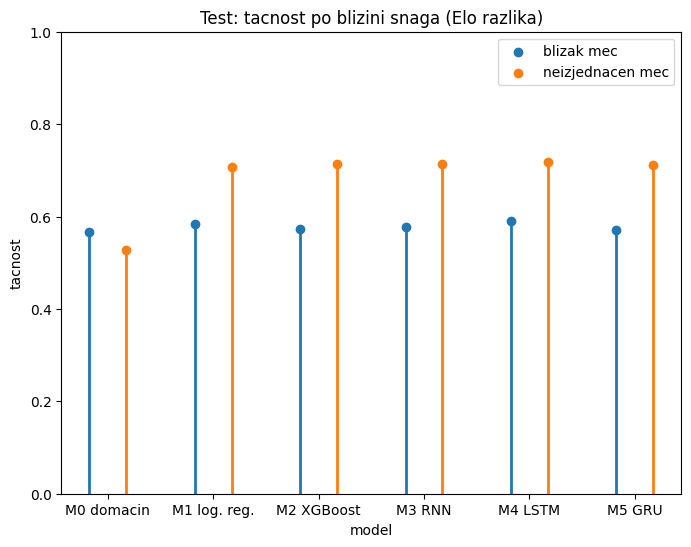

grupa,blizak mec,neizjednacen mec
model,,
M0 domacin,0.566524,0.527244
M1 log. reg.,0.583691,0.706731
M2 XGBoost,0.573677,0.713141
M3 RNN,0.577969,0.714744
M4 LSTM,0.590844,0.717949
M5 GRU,0.570815,0.711538


In [18]:
df_elo_gap_test = accuracy_by_group(y_test_true, predictions_test, is_close_game_test, "blizak mec", "neizjednacen mec")
plot_accuracy_by_group(df_elo_gap_test, "Test: tacnost po blizini snaga (Elo razlika)")
df_elo_gap_test.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

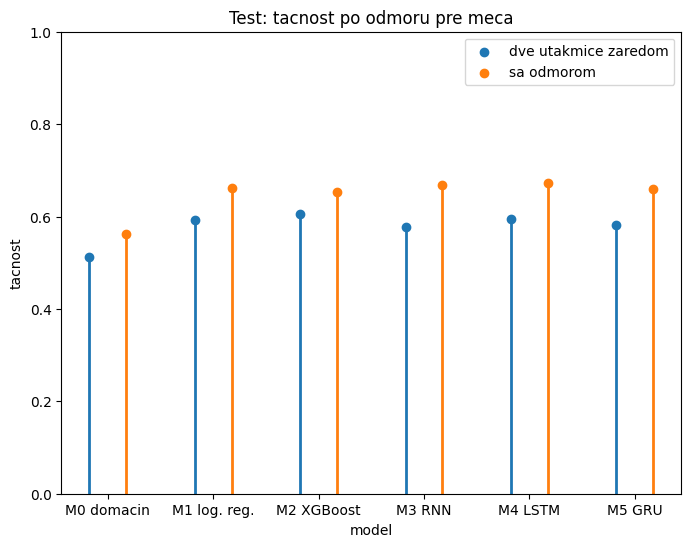

grupa,dve utakmice zaredom,sa odmorom
model,,
M0 domacin,0.511936,0.562368
M1 log. reg.,0.591512,0.661734
M2 XGBoost,0.604775,0.653277
M3 RNN,0.578249,0.668076
M4 LSTM,0.594164,0.673362
M5 GRU,0.580902,0.659619


In [19]:
df_rest_test = accuracy_by_group(y_test_true, predictions_test, is_back_to_back_test, "dve utakmice zaredom", "sa odmorom")
plot_accuracy_by_group(df_rest_test, "Test: tacnost po odmoru pre meca")
df_rest_test.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

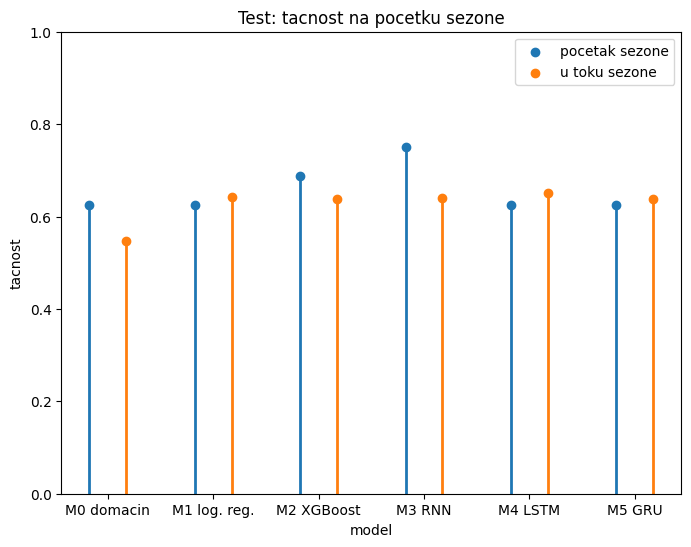

grupa,pocetak sezone,u toku sezone
model,,
M0 domacin,0.6250,0.547054
M1 log. reg.,0.6250,0.641928
M2 XGBoost,0.6875,0.638868
M3 RNN,0.7500,0.641163
M4 LSTM,0.6250,0.651109
M5 GRU,0.6250,0.637337


In [20]:
df_season_test = accuracy_by_group(y_test_true, predictions_test, is_season_start_test, "pocetak sezone", "u toku sezone")
plot_accuracy_by_group(df_season_test, "Test: tacnost na pocetku sezone")
df_season_test.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

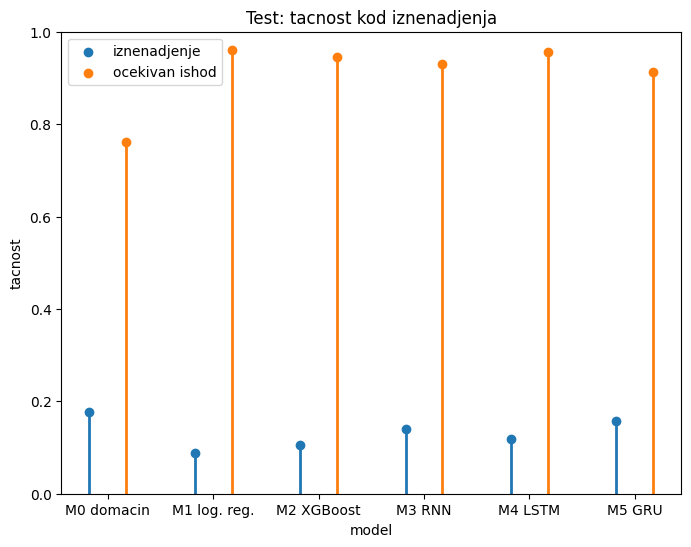

grupa,iznenadjenje,ocekivan ishod
model,,
M0 domacin,0.176349,0.760999
M1 log. reg.,0.087137,0.959572
M2 XGBoost,0.105809,0.945303
M3 RNN,0.141079,0.929845
M4 LSTM,0.118257,0.956005
M5 GRU,0.157676,0.912010


In [21]:
df_upset_test = accuracy_by_group(y_test_true, predictions_test, is_upset_test, "iznenadjenje", "ocekivan ishod")
plot_accuracy_by_group(df_upset_test, "Test: tacnost kod iznenadjenja")
df_upset_test.pivot(index="model", columns="grupa", values="tacnost").loc[plotting.MODEL_ORDER]

Dva najjača nalaza sa validacije se potvrđuju na testu, gotovo bez promene. Kod iznenađenja: tačnost na 482 test-meča gde je favorit izgubio (36.4% od 1323) pada na 9-16% za M1-M5, naspram 91-96% na 841 meča sa očekivanim ishodom - isti raspon kao na validaciji (7-16% naspram 93-97%). Kod blizine snaga: tačnost na 699 bliskih test-mečeva je 57-59%, naspram 71-72% na 624 neizjednačena - opet isti obrazac kao na validaciji (60-61% naspram 71%).

Preostala dva nalaza se **ne** potvrđuju - i to je samo po sebi poučno. Odmor menja predznak: na validaciji su modeli bili blago tačniji posle dve utakmice zaredom (+1 do +1.5 p.p.), na testu su blago netačniji (-6 do -9 p.p. za M1-M5). Suprotan smer između dva skupa je jak znak da je validacioni nalaz bio šum, ne stvaran efekat - tačno onako kako je zaključak sa validacije već upozoravao. Početak sezone ostaje šum na oba skupa: 32 meča na validaciji, svega 16 na testu, premalo da bilo šta pokaže.

Provera time razdvaja stvarna, prenosiva ograničenja modela (iznenađenje, blizina snaga) od nalaza koji su bili šum od početka (odmor, početak sezone).

## Zaključak

Četiri tipa mečeva daju vrlo različitu sliku na validaciji, a provera na testu (iznad) razdvaja stvarne nalaze od šuma.

**Iznenađenja su glavni izvor grešaka, na oba skupa i podjednako kod svih pet netrivijalnih modela.** Kad favorit (veći Elo, uz `ELO_HOME_BONUS` za domaćina) pobedi, M1-M5 pogađaju 93-97% takvih mečeva na validaciji i 91-96% na testu; kad favorit izgubi (908 od 2624 mečeva na validaciji, 482 od 1323 na testu), tačnost pada na 7-16% na oba skupa. Ovo nije slabost jednog modela - svi, uključujući mreže, u praksi nauče "predvidi favorita", u skladu sa nalazom iz sveske 03 da Elo rejting dominira uticajem na predikciju. Iznenađenja ostaju suštinski teško predvidljiva iz istorijskih atributa, i to se ne menja van validacije.

**Bliski mečevi su teži za svaki netrivijalni model, na oba skupa.** Tačnost pada sa ~71% na neizjednačenim mečevima na ~60-61% na validaciji i ~57-59% na testu, na mečevima gde je razlika u Elo rejtingu ispod medijane izmerene na validaciji (93.6 poena). M0 pokazuje mnogo manji pad jer ne koristi Elo uopšte - njegova "tačnost" po ovoj podeli je slučajna, ne stvarna osetljivost na blizinu snaga. Ovo je i očekivano: bliski mečevi imaju ishod bliži nasumičnom po definiciji.

**Odmor i početak sezone su bili šum, ne signal - provera na testu to potvrđuje.** Na validaciji su modeli bili blago tačniji posle dve utakmice zaredom (729 mečeva, +1 do +1.5 p.p.); na testu je predznak suprotan (-6 do -9 p.p.). Promena predznaka između skupova je jasan znak šuma, ne stvarnog efekta - reda veličine Wilson intervala iz sveske 05 (±1.8 p.p. na celoj validaciji). Početak sezone ima premalo mečeva na oba skupa (32 na validaciji, 16 na testu) da bilo šta pokaže.

Zaključak: modeli ne greše nasumično, greše sistematski tamo gde je ishod suštinski neizvesniji (blizak meč, iznenađenje) - to je granica koju daju raspoloživi atributi, potvrđena na oba skupa, ne mana konkretne arhitekture. Razlike između M1-M5 unutar svake kategorije su reda veličine manje od razlika između kategorija, u skladu sa nalazom iz ostatka projekta da su rekurentne mreže, XGBoost i logistička regresija međusobno praktično nerazlučivi.